# Experiment 5: Content-Based Analysis (Social Media + NLP)

In [2]:
# Install (if needed)
!pip install pandas numpy matplotlib seaborn nltk textblob emoji wordcloud scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
import emoji
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import random

nltk.download('stopwords', quiet=True)
sns.set_style('whitegrid')

In [4]:
# Generate synthetic posts
np.random.seed(42)
random.seed(42)

templates = [
"I love the new {} 😍🔥",
"The {} battery drains too fast 😡",
"{} performance is smooth and gaming awesome 🎮",
"Having heating issues with {} 😓",
"Just bought the {} - amazing design 😎",
"Worst customer service ever for {} 😤",
"Great discount on {} 💸",
"{} delivery was late again 😠",
"Check out this new {} feature #tech",
"{} is okay but not great 😐"
]

products = ["iPhone 15","Samsung S23","Pixel 8","OnePlus 12","Xiaomi 14"]

posts = []
for _ in range(150):
    posts.append(random.choice(templates).format(random.choice(products)))

df = pd.DataFrame({'post': posts})
df.head()

,post
0,The iPhone 15 battery drains too fast 😡
1,Just bought the Samsung S23 - amazing design 😎
2,Having heating issues with Samsung S23 😓
3,The Xiaomi 14 battery drains too fast 😡
4,The Xiaomi 14 battery drains too fast 😡


In [5]:
# Text cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    return text

df['clean_for_sentiment'] = df['post'].apply(clean_text)

def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    return ' '.join([w for w in text.split() if w not in stop_words])

df['processed_text'] = df['clean_for_sentiment'].apply(remove_stopwords)

In [6]:
# Sentiment Analysis
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    return 'Neutral'

df['sentiment'] = df['clean_for_sentiment'].apply(get_sentiment)
df[['post','sentiment']].head(10)

,post,sentiment
0,The iPhone 15 battery drains too fast 😡,Positive
1,Just bought the Samsung S23 - amazing design 😎,Positive
2,Having heating issues with Samsung S23 😓,Neutral
3,The Xiaomi 14 battery drains too fast 😡,Positive
4,The Xiaomi 14 battery drains too fast 😡,Positive
5,Great discount on iPhone 15 💸,Positive
6,I love the new iPhone 15 😍🔥,Positive
7,Having heating issues with Samsung S23 😓,Neutral
8,Check out this new Xiaomi 14 feature #tech,Positive
9,I love the new Xiaomi 14 😍🔥,Positive


In [7]:
# Emoji extraction
def extract_emojis(text):
    return [c for c in text if c in emoji.EMOJI_DATA]

df['emojis'] = df['post'].apply(extract_emojis)
all_emojis = sum(df['emojis'], [])
emoji_counts = Counter(all_emojis)
emoji_counts.most_common(5)

[('😓', 22), ('😡', 18), ('😠', 17), ('😎', 14), ('🎮', 14)]

In [8]:
# Topic Modeling (LDA)
vectorizer = CountVectorizer(max_features=100, stop_words='english')
dtm = vectorizer.fit_transform(df['processed_text'])

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(dtm)

feature_names = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    print(f"Topic {i+1}:", [feature_names[j] for j in topic.argsort()[-10:]])

Topic 1: ['great', 'smooth', 'gaming', 'performance', 'awesome', 'fast', 'drains', 'battery', 'oneplus', '12']
Topic 2: ['late', 'delivery', 'great', 'heating', 'issues', 'new', 'iphone', '15', 'xiaomi', '14']
Topic 3: ['15', 'iphone', 'design', 'bought', 'amazing', 'service', 'worst', 'customer', 'samsung', 's23']


In [9]:
# Trending words
words = ' '.join(df['processed_text']).split()
freq = Counter(words)
freq.most_common(10)

[('iphone', 39),
 ('15', 39),
 ('xiaomi', 34),
 ('14', 34),
 ('samsung', 32),
 ('s23', 32),
 ('new', 28),
 ('oneplus', 26),
 ('12', 26),
 ('great', 23)]

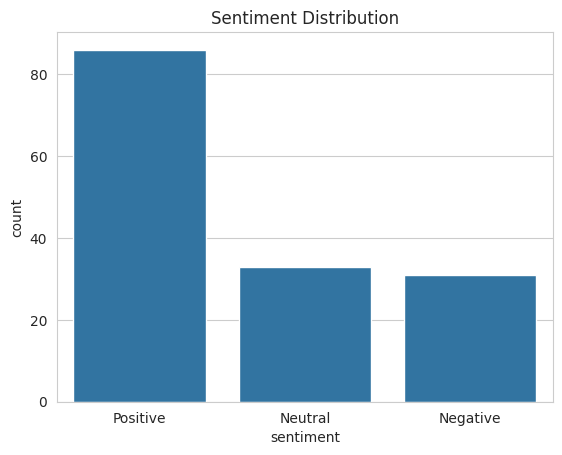

In [10]:
# Visualization
plt.figure()
sns.countplot(x='sentiment', data=df, order=['Positive','Neutral','Negative'])
plt.title('Sentiment Distribution')
plt.show()